# Beta Kernel: Exact vs RFF Approximation

This notebook demonstrates the Random Fourier Feature (RFF) approximation for the Beta kernel.

## Kernel Definition

The Beta kernel is defined as:
$$k(x, x') = \frac{B(\beta + \|x - x'\|^\alpha, \gamma)}{B(\beta, \gamma)}$$

where B is the Beta function and:
- $\alpha \in (0, 2]$ controls the exponent
- $\beta > 0$ is the first Beta parameter
- $\gamma > 0$ is the second Beta parameter

### Spectral Mixing Distribution
The mixing distribution R follows a Beta-exponential distribution:
$$R = -\log(X), \quad X \sim \text{Beta}(\beta, \gamma)$$

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/GeneralizedRFF.jl`


In [2]:
using GeneralizedRFF
using KernelFunctions
using KernelFunctions: ColVecs
using AbstractGPs
using Random
using LinearAlgebra
using Plots
gr()

Random.seed!(42)

TaskLocalRNG()

## 1. Kernel Profile Comparison

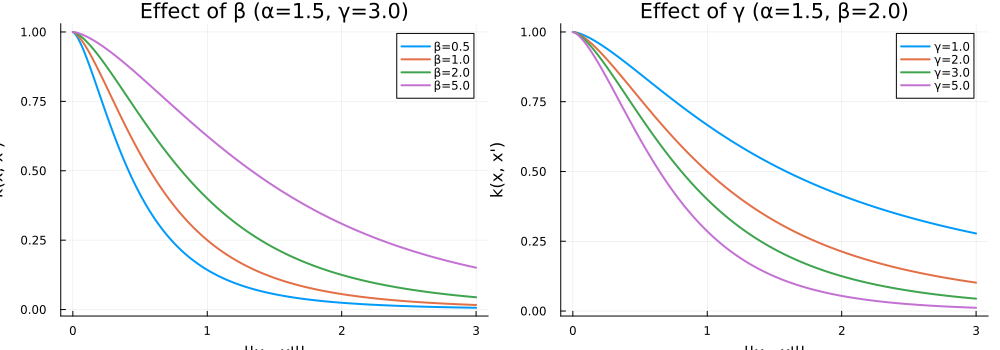

In [3]:
# Compare different parameter combinations
x_range = range(0, 3, length=200)

# Vary beta with fixed alpha, gamma
p_beta = plot(title="Effect of β (α=1.5, γ=3.0)", xlabel="||x - x'||", ylabel="k(x, x')")
for β in [0.5, 1.0, 2.0, 5.0]
    k = BetaKernel(α=1.5, β=β, γ=3.0)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_beta, x_range, y_k, label="β=$β", linewidth=2)
end

# Vary gamma with fixed alpha, beta
p_gamma = plot(title="Effect of γ (α=1.5, β=2.0)", xlabel="||x - x'||", ylabel="k(x, x')")
for γ in [1.0, 2.0, 3.0, 5.0]
    k = BetaKernel(α=1.5, β=2.0, γ=γ)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_gamma, x_range, y_k, label="γ=$γ", linewidth=2)
end

plot(p_beta, p_gamma, layout=(1, 2), size=(1000, 350))

## 2. Kernel Matrix Comparison (Heatmap)

In [4]:
# Define kernel
k = BetaKernel(α=1.5, β=2.0, γ=3.0)
println("Kernel: ", k)

Kernel: Beta Kernel (α = 1.5, β = 2.0 γ =3.0 metric = Distances.Euclidean(0.0))


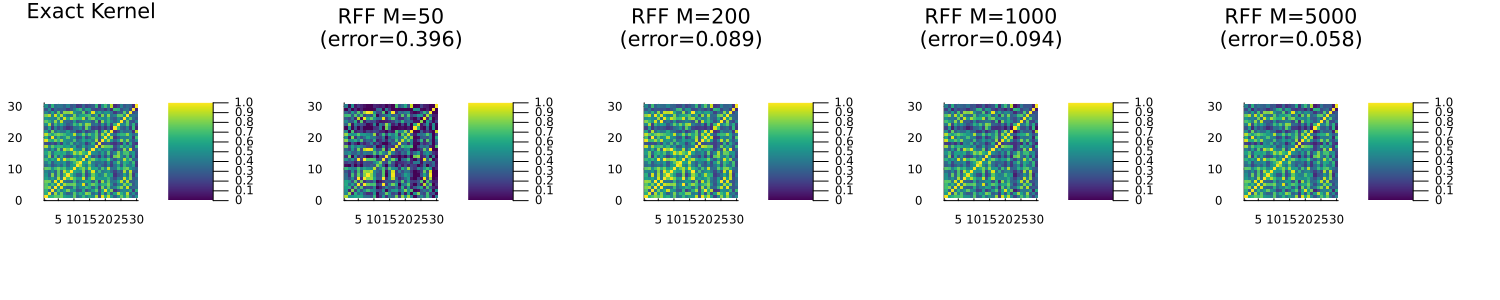

In [5]:
# Generate test data
n = 30
X = [rand(2) * 2 for _ in 1:n]

# Exact kernel matrix
K_exact = kernelmatrix(k, X)

# RFF approximation with different M values
M_values = [50, 200, 1000, 5000]

plots = [heatmap(K_exact, title="Exact Kernel", c=:viridis, aspect_ratio=1, clim=(0, 1))]

for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(plots, heatmap(K_approx, title="RFF M=$M\n(error=$(round(rel_error, digits=3)))", 
                         c=:viridis, aspect_ratio=1, clim=(0, 1)))
end

plot(plots..., layout=(1, 5), size=(1500, 300))

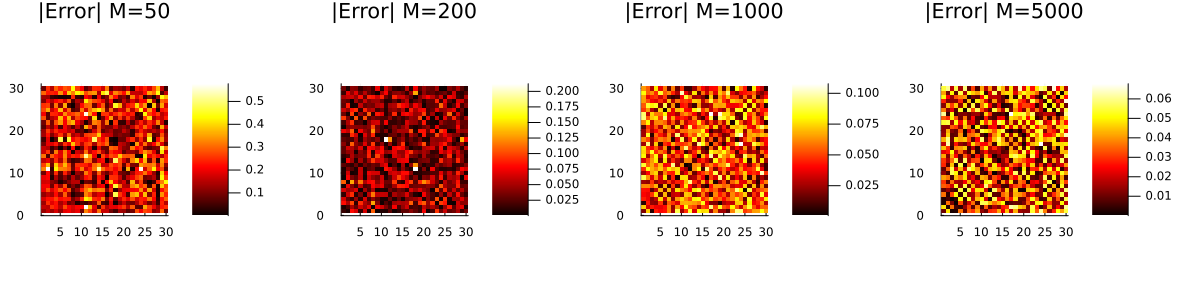

In [6]:
# Error difference heatmaps
error_plots = []
for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    K_diff = abs.(K_exact - K_approx)
    push!(error_plots, heatmap(K_diff, title="|Error| M=$M", c=:hot, aspect_ratio=1))
end

plot(error_plots..., layout=(1, 4), size=(1200, 300))

## 3. Convergence Analysis

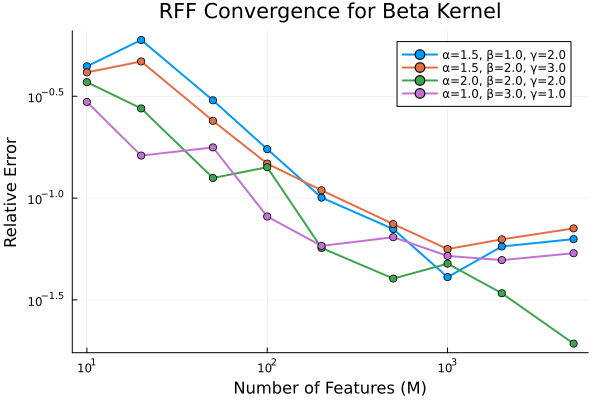

In [7]:
# Analyze convergence for different parameter combinations
M_range = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

param_sets = [
    (1.5, 1.0, 2.0),
    (1.5, 2.0, 3.0),
    (2.0, 2.0, 2.0),
    (1.0, 3.0, 1.0)
]

p_conv = plot(title="RFF Convergence for Beta Kernel",
              xlabel="Number of Features (M)", ylabel="Relative Error",
              xscale=:log10, yscale=:log10, legend=:topright)

for (α, β, γ) in param_sets
    k_param = BetaKernel(α=α, β=β, γ=γ)
    K_exact_param = kernelmatrix(k_param, X)
    
    errors = Float64[]
    for M in M_range
        K_approx = rff_kernelmatrix(MersenneTwister(42), k_param, X, M)
        rel_error = norm(K_exact_param - K_approx) / norm(K_exact_param)
        push!(errors, rel_error)
    end
    
    plot!(p_conv, M_range, errors, marker=:circle, label="α=$α, β=$β, γ=$γ", linewidth=2)
end

p_conv

## 4. 1D Gaussian Process Comparison

In [8]:
# RFF approximation for GP
function rff_gp_predict(k, X_train, y_train, X_test, M; noise=0.1)
    rng = MersenneTwister(42)
    d = length(first(X_train))
    basis = sample_generalized_rff_basis(rng, k, d, M)
    
    Phi_train_mat = hcat(X_train...)
    Phi_test_mat = hcat(X_test...)
    
    features_train = basis(ColVecs(Phi_train_mat))
    features_test = basis(ColVecs(Phi_test_mat))
    
    Phi_train = hcat([features_train[i] for i in 1:length(X_train)]...)'
    Phi_test = hcat([features_test[i] for i in 1:length(X_test)]...)'
    
    n, m = size(Phi_train)
    A = Phi_train' * Phi_train + noise^2 * I(m)
    w_mean = A \ (Phi_train' * y_train)
    
    m_pred = Phi_test * w_mean
    Sigma_w = noise^2 * inv(A)
    v_pred = [Phi_test[i, :]' * Sigma_w * Phi_test[i, :] + noise^2 for i in 1:size(Phi_test, 1)]
    
    return m_pred, sqrt.(v_pred)
end

rff_gp_predict (generic function with 1 method)

In [9]:
# Generate 1D data
n_train = 10
x_train = sort(rand(n_train) * 4 .- 2)
y_train = sin.(2 * x_train) .+ 0.2 * randn(n_train)

x_test = range(-2.5, 2.5, length=200)

X_train = [[x] for x in x_train]
X_test = [[x] for x in x_test]

# Exact GP
k_1d = BetaKernel(α=1.5, β=2.0, γ=3.0)
f_exact = GP(k_1d)
fx_exact = f_exact(X_train, 0.1)
p_exact = posterior(fx_exact, y_train)

m_exact = mean(p_exact(X_test))
s_exact = sqrt.(var(p_exact(X_test)))

200-element Vector{Float64}:
 0.9875600436169535
 0.9868143642407393
 0.9860215058605489
 0.9851783839724868
 0.9842817110084643
 0.9833279833811731
 0.9823134677860103
 0.9812341867297611
 0.9800859032564615
 0.978864104841815
 0.9775639864289096
 0.9761804325798119
 0.9747079987199823
 ⋮
 0.6327316940316604
 0.6531281465065215
 0.6725185317733451
 0.6909372673285472
 0.7084195496663565
 0.7250009715696082
 0.7407172220144199
 0.7556038462911772
 0.7696960516380839
 0.7830285484584238
 0.795635420206701
 0.8075500169633835

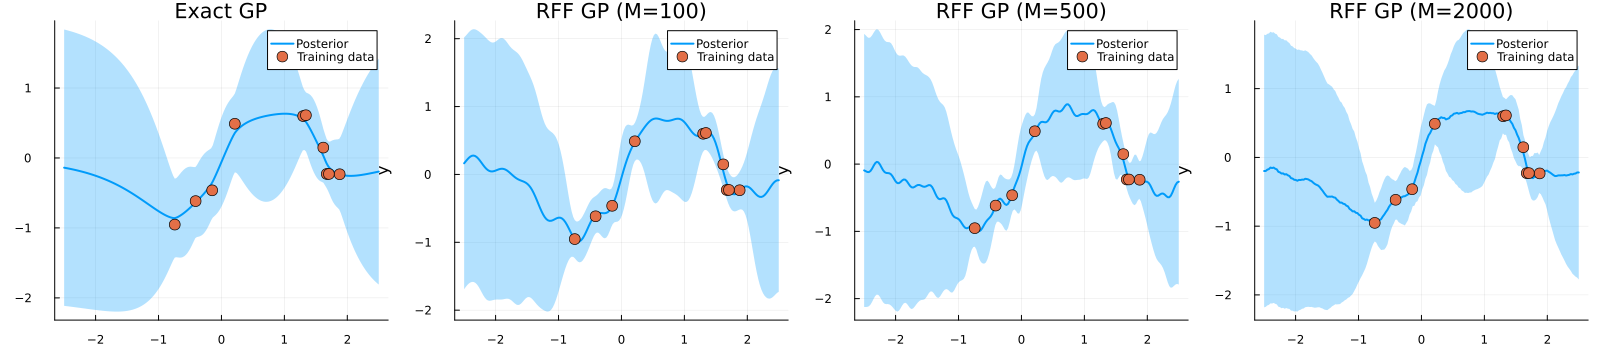

In [10]:
# Compare GP predictions
p1 = plot(title="Exact GP", xlabel="x", ylabel="y", legend=:topright)
plot!(p1, x_test, m_exact, ribbon=2*s_exact, fillalpha=0.3, label="Posterior", linewidth=2)
scatter!(p1, x_train, y_train, label="Training data", markersize=6)

M_vals = [100, 500, 2000]
rff_plots = []
for M in M_vals
    m_rff, s_rff = rff_gp_predict(k_1d, X_train, y_train, X_test, M)
    p = plot(title="RFF GP (M=$M)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Training data", markersize=6)
    push!(rff_plots, p)
end

plot(p1, rff_plots..., layout=(1, 4), size=(1600, 350))

## 5. 2D Gaussian Process Comparison

In [11]:
# Generate 2D data
n_train_2d = 30
X_train_2d = [rand(2) * 4 .- 2 for _ in 1:n_train_2d]
y_train_2d = [sin(x[1]) * cos(x[2]) + 0.1 * randn() for x in X_train_2d]

# Test grid
x1_range = range(-2.5, 2.5, length=40)
x2_range = range(-2.5, 2.5, length=40)
X_test_2d = [[x1, x2] for x1 in x1_range for x2 in x2_range]

1600-element Vector{Vector{Float64}}:
 [-2.5, -2.5]
 [-2.5, -2.371794871794872]
 [-2.5, -2.2435897435897436]
 [-2.5, -2.1153846153846154]
 [-2.5, -1.9871794871794872]
 [-2.5, -1.858974358974359]
 [-2.5, -1.7307692307692308]
 [-2.5, -1.6025641025641026]
 [-2.5, -1.4743589743589745]
 [-2.5, -1.3461538461538463]
 [-2.5, -1.2179487179487178]
 [-2.5, -1.0897435897435896]
 [-2.5, -0.9615384615384616]
 ⋮
 [2.5, 1.0897435897435896]
 [2.5, 1.2179487179487178]
 [2.5, 1.3461538461538463]
 [2.5, 1.4743589743589745]
 [2.5, 1.6025641025641026]
 [2.5, 1.7307692307692308]
 [2.5, 1.858974358974359]
 [2.5, 1.9871794871794872]
 [2.5, 2.1153846153846154]
 [2.5, 2.2435897435897436]
 [2.5, 2.371794871794872]
 [2.5, 2.5]

In [12]:
# Exact GP for 2D
k_2d = BetaKernel(α=1.5, β=2.0, γ=3.0)
f_exact_2d = GP(k_2d)
fx_exact_2d = f_exact_2d(X_train_2d, 0.1)
p_exact_2d = posterior(fx_exact_2d, y_train_2d)

m_exact_2d = mean(p_exact_2d(X_test_2d))
m_exact_grid = reshape(m_exact_2d, length(x1_range), length(x2_range))

40×40 Matrix{Float64}:
 -0.0429445  -0.041924   -0.0403337  …  -0.110886   -0.0894038  -0.0691005
 -0.0506933  -0.049758   -0.048132      -0.114541   -0.0887272  -0.0652747
 -0.0601575  -0.0594249  -0.0578433     -0.11069    -0.0808617  -0.0550004
 -0.0717454  -0.0714066  -0.0700137     -0.0952561  -0.0628668  -0.0362577
 -0.0859369  -0.0862951  -0.085345      -0.0639736  -0.0320726  -0.0074349
 -0.103265   -0.104782   -0.104704   …  -0.0141204   0.012881    0.0320394
 -0.124272   -0.127612   -0.129083       0.0535713   0.0710752   0.0811543
 -0.149432   -0.155484   -0.159483       0.134628    0.139039    0.13713
 -0.179058   -0.188912   -0.196698       0.222032    0.211165    0.195651
 -0.2132     -0.228076   -0.241076       0.306943    0.280333    0.251443
 -0.251567   -0.27272    -0.292383   …   0.378576    0.338901    0.2993
 -0.293477   -0.322115   -0.349815       0.426969    0.381193    0.335634
 -0.337819   -0.375036   -0.412046       0.451971    0.406726    0.359824
  ⋮        

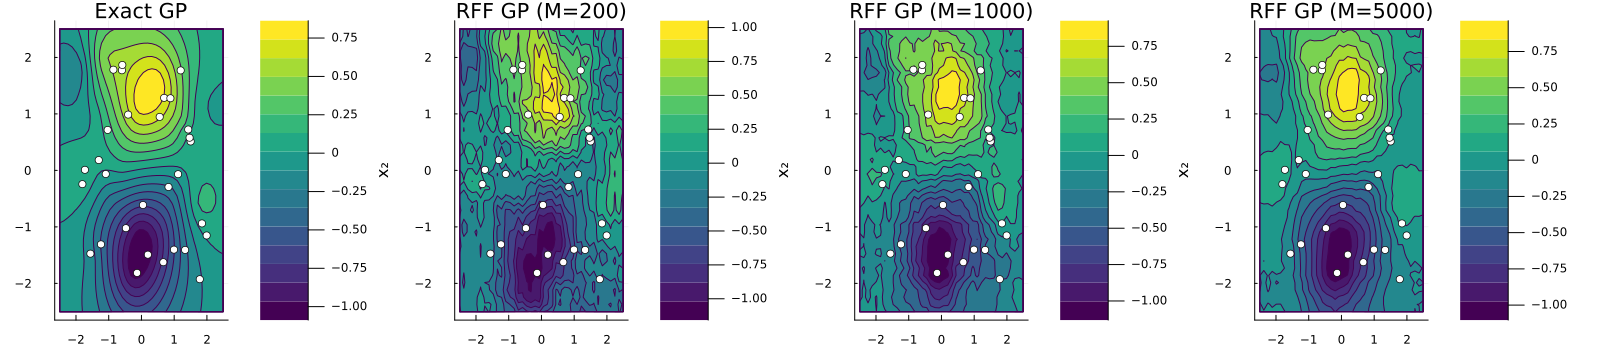

In [13]:
# Plot 2D comparison
p_exact_plot = contourf(x1_range, x2_range, m_exact_grid', 
                        title="Exact GP", xlabel="x₁", ylabel="x₂", c=:viridis)
scatter!(p_exact_plot, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
         c=:white, markersize=4, label="")

rff_2d_plots = [p_exact_plot]
for M in [200, 1000, 5000]
    m_rff_2d, _ = rff_gp_predict(k_2d, X_train_2d, y_train_2d, X_test_2d, M)
    m_rff_grid = reshape(m_rff_2d, length(x1_range), length(x2_range))
    
    p_rff = contourf(x1_range, x2_range, m_rff_grid', 
                     title="RFF GP (M=$M)", xlabel="x₁", ylabel="x₂", c=:viridis)
    scatter!(p_rff, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
             c=:white, markersize=4, label="")
    push!(rff_2d_plots, p_rff)
end

plot(rff_2d_plots..., layout=(1, 4), size=(1600, 350))

## 6. Relationship with Beta Function

The Beta kernel is uniquely characterized by its use of the Beta function ratio.

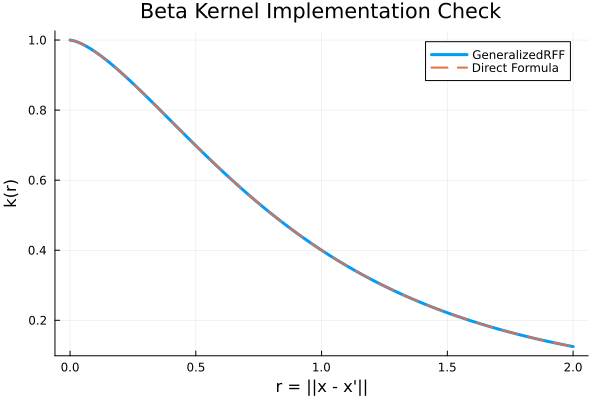

In [14]:
# Visualize the Beta kernel behavior
using SpecialFunctions: logbeta

# Direct computation of Beta kernel
function beta_kernel_direct(r, α, β, γ)
    log_ratio = logbeta(β + r^α, γ) - logbeta(β, γ)
    return exp(log_ratio)
end

# Compare direct computation with GeneralizedRFF implementation
r_vals = range(0, 2, length=100)
α, β, γ = 1.5, 2.0, 3.0

k_impl = BetaKernel(α=α, β=β, γ=γ)
y_impl = [k_impl([0.0], [r]) for r in r_vals]
y_direct = [beta_kernel_direct(r, α, β, γ) for r in r_vals]

p = plot(title="Beta Kernel Implementation Check", xlabel="r = ||x - x'||", ylabel="k(r)")
plot!(p, r_vals, y_impl, label="GeneralizedRFF", linewidth=3)
plot!(p, r_vals, y_direct, label="Direct Formula", linewidth=2, linestyle=:dash)
p

## Summary

The Beta kernel RFF approximation:
- Uses a Beta-exponential distribution ($R = -\log(\text{Beta})$) as the mixing distribution
- The kernel decays faster than Gaussian for large distances
- RFF approximation captures the kernel behavior well
- Parameters β and γ control the decay rate and shape